In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

In [2]:
adata = sc.read_h5ad('../../data/figure-inputs/scrna_objects/plasma-residual-labelled.h5ad')

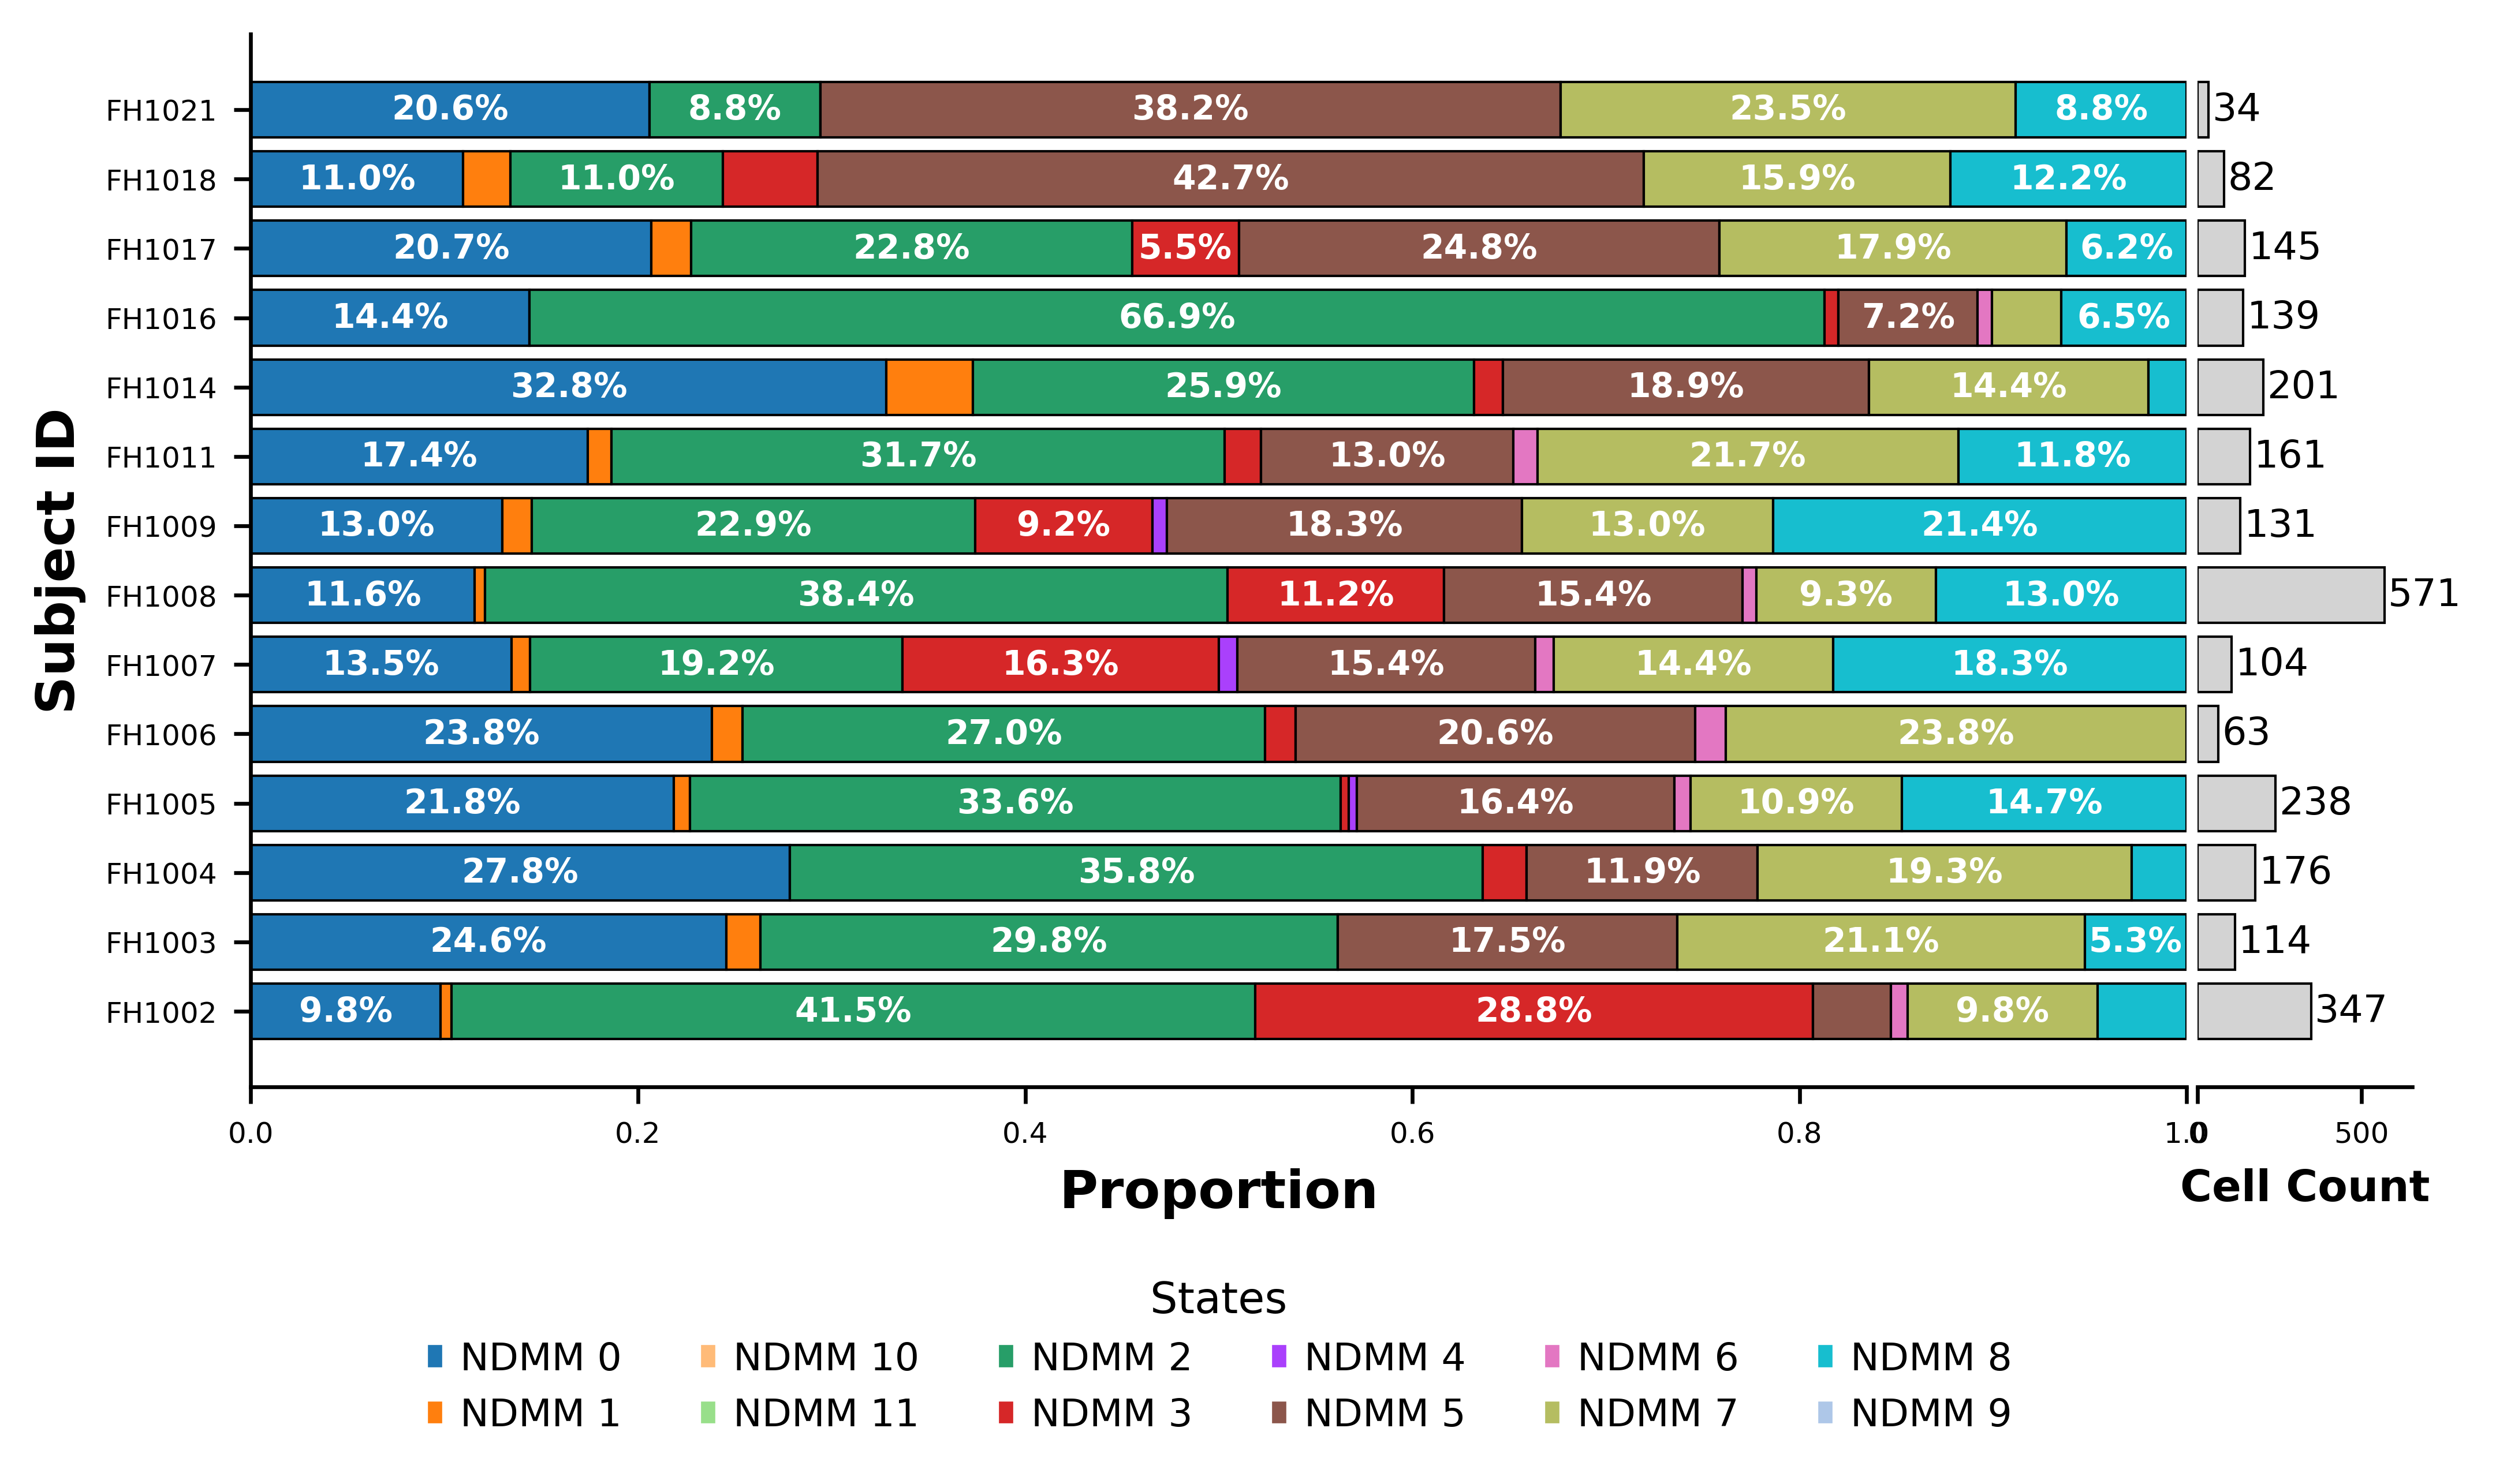

In [3]:
plt.style.use('default')
sc.settings.set_figure_params(
    dpi=80,
    facecolor='white',
    frameon=False,
    fontsize=6,
    dpi_save=300,
    figsize=(5, 4),
    format='png'
)

color_dict = {'NDMM 0': '#1f77b4',
 'NDMM 1': '#ff7f0e',
 'NDMM 2': '#279e68',
 'NDMM 3': '#d62728',
 'NDMM 4': '#aa40fc',
 'NDMM 5': '#8c564b',
 'NDMM 6': '#e377c2',
 'NDMM 7': '#b5bd61',
 'NDMM 8': '#17becf',
 'NDMM 9': '#aec7e8',
 'NDMM 10': '#ffbb78',
 'NDMM 11': '#98df8a'}

# Prepare data
plot_data = adata.obs[["subject.subjectGuid", "plasma_labels_knn"]].copy()
plot_data["count"] = 1

# Sort subjects and calculate proportions
subjects_sorted = sorted(plot_data["subject.subjectGuid"].unique())
subject_counts = plot_data["subject.subjectGuid"].value_counts()
total_cells = len(plot_data)
subject_proportions = (subject_counts / total_cells * 100).loc[subjects_sorted]
subject_actual_counts = subject_counts.loc[subjects_sorted]

# Create figure with main plot and side bar
fig = plt.figure(figsize=(8, 4), dpi=300)
gs = fig.add_gridspec(1, 2, width_ratios=[4.5, 0.5], wspace=0.01)
ax_main = fig.add_subplot(gs[0])
ax_side = fig.add_subplot(gs[1])

# Main plot: stacked horizontal bar chart
for subject in subjects_sorted:
    subset = plot_data[plot_data["subject.subjectGuid"] == subject]
    props = subset["plasma_labels_knn"].value_counts(normalize=True).sort_index()
    bottom = 0
    
    for state in props.index:
        prop = props[state]
        color = color_dict[state]
        ax_main.barh(subject, prop, left=bottom, color=color, 
                     edgecolor="black", linewidth=0.5)
        
        # Add percentage text if proportion > 5%
        if prop > 0.05:
            ax_main.text(bottom + prop / 2, subject, f"{prop*100:.1f}%",
                        ha="center", va="center", fontsize=7,
                        fontweight="bold", color="white")
        bottom += prop

ax_main.set_xlabel("Proportion", fontsize=11, fontweight="semibold")
ax_main.set_ylabel("Subject ID", fontsize=11, fontweight="semibold")
# ax_main.set_title("Malignant Plasma States after PreTx", fontsize=13, fontweight="bold", pad=15)
ax_main.set_xlim(0, 1)
ax_main.spines["top"].set_visible(False)
ax_main.spines["right"].set_visible(False)
ax_main.grid(visible=None)

# Side bar: actual cell counts per subject
ax_side.barh(subjects_sorted, subject_actual_counts.values, 
             color="lightgray", edgecolor="black", linewidth=0.5)

for subject, count in zip(subjects_sorted, subject_actual_counts.values):
    ax_side.text(count + max(subject_actual_counts.values) * 0.02, subject, 
                f"{count}", va="center", fontsize=8)

ax_side.set_xlabel("Cell Count", fontsize=9, fontweight="semibold")
ax_side.set_xlim(0, max(subject_actual_counts.values) * 1.15)
ax_side.set_yticks([])
ax_side.grid(visible=None)
ax_side.spines["top"].set_visible(False)
ax_side.spines["right"].set_visible(False)
ax_side.spines["left"].set_visible(False)

states = sorted(color_dict.keys())
legend_elements = [
    mpatches.Patch(facecolor=color_dict[state], edgecolor="white", 
                   label=state, linewidth=1)
    for state in states
]
ax_main.legend(handles=legend_elements, loc="upper center",
               bbox_to_anchor=(0.5, -0.15), ncol=min(6, len(states)),
               frameon=False, fontsize=8, title="States", title_fontsize=9)

plt.show()

In [4]:
fig.savefig("../../data/figure-outputs/supplementary-1/sup_1k.pdf", bbox_inches="tight", dpi=300, format="pdf")